In [5]:
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps xformers trl peft accelerate bitsandbytes
 
print("Unsloth installed successfully!")

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-igp9g0f5/unsloth_c24ccc2eafde44ee9931affc7b8d1e07
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-igp9g0f5/unsloth_c24ccc2eafde44ee9931affc7b8d1e07
  Resolved https://github.com/unslothai/unsloth.git to commit 1d8160376e169d13c386b7ef4bc1fdc8f855de68
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Unsloth installed successfully!


In [6]:
import os
from datasets import load_dataset

from unsloth import FastLanguageModel, is_bfloat16_supported
from unsloth.chat_templates import get_chat_template
from trl import SFTTrainer, SFTConfig


# Config

MODEL_NAME = "unsloth/Llama-3.1-8B-Instruct-bnb-4bit"
TRAIN_FILE = "/kaggle/input/datasets/peach2547/final-datasets/train.jsonl"
DEV_FILE   = "/kaggle/input/datasets/peach2547/final-datasets/valid.jsonl"
OUTPUT_DIR = "./outputs/unsloth_llama31_qlora"

MAX_SEQ_LENGTH = 1024
SEED = 42


model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype          = None,
    load_in_4bit   = True,
)

tokenizer = get_chat_template(
    tokenizer,
    chat_template = "llama-3.1",
)

print("eos_token:", tokenizer.eos_token, tokenizer.eos_token_id)
print("pad_token:", tokenizer.pad_token, tokenizer.pad_token_id)

model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha = 32,
    lora_dropout = 0.05,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = SEED,
    use_rslora = False,
    loftq_config = None,
)

raw_datasets = load_dataset(
    "json",
    data_files = {
        "train": TRAIN_FILE,
        "validation": DEV_FILE,
    },
)

INSTRUCTION = (
    "Bạn là chuyên gia đánh giá chất lượng văn bản tiếng Việt. "
    "Hãy đọc văn bản đầu vào và trả về đúng một JSON duy nhất theo định dạng: "
    "{\"Coherence\": <1-5>, \"Fluency\": <1-5>}. "
    "Chỉ trả về JSON, không giải thích thêm."
)

def map_conversation_to_prompt_completion(examples):
    prompts = []
    completions = []

    for messages in examples["messages"]:
        if not isinstance(messages, list) or len(messages) < 2:
            raise ValueError(f"Sample không hợp lệ: {messages}")

        if messages[-1]["role"] != "assistant":
            raise ValueError(
                f"Message cuối phải là assistant, nhưng nhận được: {messages[-1]['role']}"
            )

        source_messages = messages[:-1]
        assistant_message = messages[-1]

        input_chunks = []
        for msg in source_messages:
            if msg["role"] in ["user", "system"]:
                input_chunks.append(msg["content"].strip())

        input_text = "\n\n".join([x for x in input_chunks if x])

        user_content = (
            f"{INSTRUCTION}\n\n"
            f"Văn bản cần đánh giá:\n{input_text}"
        )

        prompts.append([
            {"role": "user", "content": user_content}
        ])
        completions.append([
            {"role": "assistant", "content": assistant_message["content"].strip()}
        ])

    return {
        "prompt": prompts,
        "completion": completions,
    }

remove_cols = raw_datasets["train"].column_names

dataset = raw_datasets.map(
    map_conversation_to_prompt_completion,
    batched=True,
    remove_columns=remove_cols,
    desc="Mapping conversation -> conversational prompt-completion",
)

print(dataset["train"][0]["prompt"])
print(dataset["train"][0]["completion"])

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset["train"],
    eval_dataset = dataset["validation"],
    args = SFTConfig(
        output_dir = OUTPUT_DIR,
        # BỎ dataset_text_field = "text"
        max_length = MAX_SEQ_LENGTH,
        num_train_epochs = 2,
        learning_rate = 2e-4,
        per_device_train_batch_size = 1,
        per_device_eval_batch_size = 1,
        gradient_accumulation_steps = 4,
        warmup_ratio = 0.03,
        lr_scheduler_type = "cosine",
        weight_decay = 0.01,
        logging_steps = 10,
        eval_strategy = "steps",
        eval_steps = 500,
        save_strategy = "steps",
        save_steps = 500,
        save_total_limit = 2,
        load_best_model_at_end = True,
        metric_for_best_model = "eval_loss",
        greater_is_better = False,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        optim = "adamw_8bit",
        seed = SEED,
        report_to = "none",
    ),
)

==((====))==  Unsloth 2026.4.4: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.1-8B-Instruct-bnb-4bit as a legacy tokenizer.


eos_token: <|eot_id|> 128009
pad_token: <|finetune_right_pad_id|> 128004


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[{'content': 'Bạn là chuyên gia đánh giá chất lượng văn bản tiếng Việt. Hãy đọc văn bản đầu vào và trả về đúng một JSON duy nhất theo định dạng: {"Coherence": <1-5>, "Fluency": <1-5>}. Chỉ trả về JSON, không giải thích thêm.\n\nVăn bản cần đánh giá:\nTại buổi tiếp xúc, các cử tri quận Ninh Kiều và quận Bình Thủy (TP Cần Thơ) đã đặt câu hỏi với Thiếu tướng Nguyễn Văn Thuận, Giám đốc Công an TP Cần Thơ, đại biểu Quốc hội về việc phòng chống tội phạm trên không gian mạng, đánh giá tình hình và các giải pháp.', 'role': 'user'}]
[{'content': '{"Coherence": 3, "Fluency": 3}', 'role': 'assistant'}]


In [3]:


train_result = trainer.train(resume_from_checkpoint="/kaggle/input/models/wangzhi0201/llama-adapter/pytorch/default/1/checkpoint-1500")
print(train_result)

model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 39,656 | Num Epochs = 2 | Total steps = 19,828
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
2000,0.115109,0.105401
2500,0.107520,0.106252
3000,0.104099,0.110752


Unsloth: Will smartly offload gradients to save VRAM!


KeyboardInterrupt: 

In [4]:
train_result = trainer.train(resume_from_checkpoint="/kaggle/input/models/wangzhi0201/llama-adapter-3000/pytorch/default/1")
print(train_result)

model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 39,656 | Num Epochs = 2 | Total steps = 19,828
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
3500,0.097513,0.100157
4000,0.103270,0.102307
4500,0.095724,0.116326
5000,0.113661,0.098173
5500,0.109436,0.097270
6000,0.104969,0.097189
6500,0.106477,0.102383


Unsloth: Will smartly offload gradients to save VRAM!


KeyboardInterrupt: 

In [9]:
train_result = trainer.train(resume_from_checkpoint="/kaggle/input/models/zhi1wang/llama-6500/pytorch/default/1")
print(train_result)

model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 39,656 | Num Epochs = 2 | Total steps = 19,828
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
7000,0.102560,0.119721
7500,0.111891,0.104694
8000,0.104054,0.098962
8500,0.083332,0.096873
9000,0.079389,0.095856
9500,0.109409,0.096174
10000,0.093005,0.093355


Unsloth: Will smartly offload gradients to save VRAM!


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

KeyboardInterrupt: 

In [3]:
train_result = trainer.train(resume_from_checkpoint="/kaggle/input/models/zhi1wang/llama-10000/pytorch/default/1")
print(train_result)

model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 39,656 | Num Epochs = 2 | Total steps = 19,828
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
10500,0.090859,0.092684
11000,0.094008,0.090980
11500,0.089718,0.092458
12000,0.082400,0.091199
12500,0.100975,0.090913
13000,0.096876,0.088605
13500,0.077619,0.087877


Unsloth: Will smartly offload gradients to save VRAM!


KeyboardInterrupt: 

In [6]:
train_result = trainer.train(resume_from_checkpoint="/kaggle/input/models/peach2547/llama-13500/pytorch/default/1")
print(train_result)

model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 39,656 | Num Epochs = 2 | Total steps = 19,828
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
14000,0.086565,0.088411
14500,0.087310,0.087018
15000,0.092004,0.085680
15500,0.087491,0.084462
16000,0.061034,0.084093
16500,0.076522,0.083287
17000,0.087301,0.082779


Unsloth: Will smartly offload gradients to save VRAM!


KeyboardInterrupt: 

In [3]:
train_result = trainer.train(resume_from_checkpoint="/kaggle/input/models/peach2547/llama-adapter-17000/pytorch/default/1")
print(train_result)

model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 39,656 | Num Epochs = 2 | Total steps = 19,828
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
17500,0.077397,0.082173
18000,0.097683,0.082130
18500,0.087894,0.081907
19000,0.089003,0.081832
19500,0.072132,0.081815


Unsloth: Will smartly offload gradients to save VRAM!


KeyboardInterrupt: 

In [8]:
train_result = trainer.train(resume_from_checkpoint="/kaggle/input/models/peach2547/adapter-19500/pytorch/default/1")
print(train_result)

model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 2
   \\   /|    Num examples = 39,656 | Num Epochs = 2 | Total steps = 19,828
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
19828,0.080976,0.081813


Unsloth: Will smartly offload gradients to save VRAM!


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

TrainOutput(global_step=19828, training_loss=0.0012956240291626241, metrics={'train_runtime': 4990.562, 'train_samples_per_second': 15.892, 'train_steps_per_second': 3.973, 'total_flos': 6.167161733755208e+17, 'train_loss': 0.0012956240291626241, 'epoch': 2.0})


('./outputs/unsloth_llama31_qlora/tokenizer_config.json',
 './outputs/unsloth_llama31_qlora/chat_template.jinja',
 './outputs/unsloth_llama31_qlora/tokenizer.json')

In [16]:
log_history = trainer.state.log_history
train_steps = []
train_losses = []

eval_steps = []
eval_losses = []

for log in log_history:
    if "loss" in log and "eval_loss" not in log:
        train_steps.append(log["step"])
        train_losses.append(log["loss"])
        
    if "eval_loss" in log:
        eval_steps.append(log["step"])
        eval_losses.append(log["eval_loss"])

In [21]:
import json
with open("train_logs.json", "w") as f:
    json.dump(train_steps, f, indent=4)

with open("eval_logs.json", "w") as f:
    json.dump(eval_steps, f, indent=4)

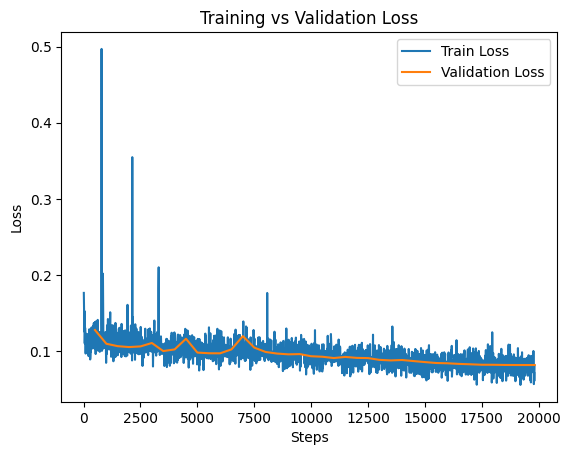

In [11]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(train_steps, train_losses, label="Train Loss")
plt.plot(eval_steps, eval_losses, label="Validation Loss")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [12]:
import zipfile
import os

def zip_folder(folder_path, zip_path):
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                
                # giữ cấu trúc thư mục
                arcname = os.path.relpath(file_path, folder_path)
                
                zipf.write(file_path, arcname)

# path adapter
folder_to_zip = "/kaggle/working/outputs/unsloth_llama31_qlora/checkpoint-19828"
zip_file = "adapter_model_LLama31_19828.zip"

zip_folder(folder_to_zip, zip_file)

print("Zip completed:", zip_file)

Zip completed: adapter_model_LLama31_19828.zip


In [13]:
from IPython.display import FileLink
# Giả sử file của bạn tên là 'result.zip' và nằm trong /kaggle/working
FileLink(r'adapter_model_LLama31_19828.zip')

/kaggle/working/adapter_model_LLama31_19828.zip

In [ ]:
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset["train"],
    eval_dataset = dataset["validation"],
    args = SFTConfig(
        output_dir = OUTPUT_DIR,
        dataset_text_field = "text",
        max_length = MAX_SEQ_LENGTH,
        num_train_epochs = 2,
        learning_rate = 2e-4,
        per_device_train_batch_size = 1,
        per_device_eval_batch_size = 1,
        gradient_accumulation_steps = 8,
        warmup_ratio = 0.03,
        lr_scheduler_type = "cosine",
        weight_decay = 0.01,
        logging_steps = 10,
        eval_strategy = "steps",
        eval_steps = 100,
        save_strategy = "steps",
        save_steps = 100,
        save_total_limit = 2,
        load_best_model_at_end = True,
        metric_for_best_model = "eval_loss",
        greater_is_better = False,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        optim = "adamw_8bit",
        seed = SEED,
        report_to = "none",
    ),
)
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|start_header_id|>user<|end_header_id|>\n\n",
    response_part    = "<|start_header_id|>assistant<|end_header_id|>\n\n",
)

train_result = trainer.train()
print(train_result)

model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

# Inference test nhanh
FastLanguageModel.for_inference(model)

test_messages = [
    {
        "role": "user",
        "content": "Tại buổi tiếp xúc, các cử tri quận Ninh Kiều và quận Bình Thủy (TP Cần Thơ) đã đặt câu hỏi với Thiếu tướng Nguyễn Văn Thuận, Giám đốc Công an TP Cần Thơ, đại biểu Quốc hội về việc phòng chống tội phạm trên không gian mạng, đánh giá tình hình và các giải pháp."
    }
]
inputs = tokenizer.apply_chat_template(
    test_messages,
    tokenize = True,
    add_generation_prompt = True,
    return_tensors = "pt",
)

# Với model split trên nhiều GPU, đưa input lên GPU đầu tiên là đủ
inputs = inputs.to("cuda:0")

outputs = model.generate(
    input_ids = inputs,
    max_new_tokens = 64,
    do_sample = False,
    use_cache = True,
)

print(tokenizer.decode(outputs[0], skip_special_tokens = True))